In [27]:
import numpy as np
import pandas as pd

## Det rigtige spørgsmål

Hvad er jeres case-mål?

Typisk vil det være én af disse:

🔹 Forudsige aflysning?

🔹 Optimere stueplanlægning?

🔹 Forudsige overskridelser?

🔹 Kapacitetsudnyttelse?

🔹 Delay prediction?

Det afgør hvad I skal bruge.

✅ Completed

→ Indeholder:

Patient alder

Speciale

Akut / planlagt

Faktiske tider

Forsinkelser

Ressourcer

Personale

❌ Cancelled

→ Indeholder kun:

Planlægningsinfo

Forventet varighed

Procedure

Stue

Dato

Import data - sep using ; 

In [28]:
df_complete = pd.read_csv(
    "../Data and descriptions/Case Rigshospitalet - Completed operations.csv",
    sep=";"
)

df_cancelled = pd.read_csv(
    "../Data and descriptions/Case Rigshospitalet - Cancelled operations.csv",
    sep=";"
)

/var/folders/t7/k_81cy8x6zg28rjf0wl09fl00000gn/T/ipykernel_88242/711997202.py:1: DtypeWarning: Columns (13,14,21,22,23,24,25,29) have mixed types. Specify dtype option on import or set low_memory=False.
  df_complete = pd.read_csv(


check for missing data

In [29]:

print("shape of completed operations:", df_complete.shape)
print("shape of cancelled operations:", df_cancelled.shape)

#check for missing values
print("Missing values in completed operations:")
print(df_complete.isnull().sum())
print("Missing values in cancelled operations:")
print(df_cancelled.isnull().sum())


shape of completed operations: (133158, 247)
shape of cancelled operations: (575, 10)
Missing values in completed operations:
Case-ID Anonymous                 0
Patient Alder                     0
Speciale                          0
Stue                            120
Operationsgang ID                 0
                              ...  
Ressource.Diodelaser næse    133154
Ressource.Øre optik 30°      133157
Ressource.Endoskop           133157
Ressource.Flexcystoskop      133156
Ressource.Kasette            133158
Length: 247, dtype: int64
Missing values in cancelled operations:
Case-ID Anonymous                                    0
Dato og tid                                          0
Primær procedure - Tekst                             0
Aflyst efter operationsprogrammet er afsluttet?      0
Aflyst på dagen for operationen?                     0
Aflysningsårsag                                    467
Forventet varighed (min.)                            0
Ombooket                   

Lav dataframe

In [30]:
df_cancelled['Dato og tid'] = pd.to_datetime(df_cancelled['Dato og tid'], format='%Y-%m-%d %H:%M:%S,%f')
df_cancelled['Dato og tid']

df_complete['Dato'] = pd.to_datetime(df_complete['Dato'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete['Dato']



0        2024-03-07
1        2024-01-05
2        2024-01-05
3        2024-01-26
4        2024-10-01
            ...    
133153   2025-12-18
133154   2025-12-23
133155   2025-12-19
133156   2025-12-22
133157   2025-12-19
Name: Dato, Length: 133158, dtype: datetime64[ns]

In [31]:
#print min og max for date for de to dataframes 
print("Cancelled operations - min date:", df_cancelled['Dato og tid'].min())
print("Cancelled operations - max date:", df_cancelled['Dato og tid'].max())
print("Completed operations - min date:", df_complete['Dato'].min())
print("Completed operations - max date:", df_complete['Dato'].max())

Cancelled operations - min date: 2024-01-03 08:05:00
Cancelled operations - max date: 2025-12-30 08:15:00
Completed operations - min date: 2024-01-01 00:00:00
Completed operations - max date: 2025-12-31 00:00:00


1. Hvorfor completed har 247 kolonner
De mange Ressource.* og Staff.* kolonner er i praksis:

One-hot encodede indikatorer (0/1)
for om en bestemt ressource eller personale-type blev brugt.
90%+ af værdierne er 0 / NaN

Det betyder:

Datasættet er meget sparse

Shape siger ikke så meget om reel informationsmængde

2. Cancelled dataset

Cancelled indeholder kun:

Planlægningsinfo

Forventet varighed

Procedure

Stue

Aflysningsårsag (men 467/575 mangler)

Det betyder:

👉 I har næsten ingen strukturel info om aflysninger
👉 I har kun planlægningsniveau

Det er faktisk meget realistisk i hospitalsdata.

In [32]:
#check for duplicates
print("Duplicate rows in completed operations:", df_complete.duplicated().sum())
print("Duplicate rows in cancelled operations:", df_cancelled.duplicated().sum())
#check for outliers
print("Summary statistics for completed operations:")
print(df_complete.describe())
print("Summary statistics for cancelled operations:")
print(df_cancelled.describe())

Duplicate rows in completed operations: 0
Duplicate rows in cancelled operations: 0
Summary statistics for completed operations:
       Case-ID Anonymous  Patient Alder  Operationsgang ID  \
count      133158.000000  133158.000000      133158.000000   
mean        60156.037437      53.788244       40663.550909   
min             1.000000       0.000000         618.000000   
25%         29928.250000      34.000000         622.000000   
50%         60097.500000      61.000000         625.000000   
75%         90338.750000      74.000000      107621.000000   
max        120868.000000     107.000000      133218.000000   
std         34927.061620      24.889920       52262.972747   

                                Dato  Forsinkelse (minutter)  \
count                         133158           132491.000000   
mean   2024-12-25 19:50:25.116027648               20.511642   
min              2024-01-01 00:00:00            -3045.000000   
25%              2024-06-20 00:00:00                0.00

In [33]:
print("Unique values in 'Procedure – Tekst & ID' column for completed operations:")
print(df_complete['Procedure - Tekst & ID'].nunique())
print("Unique values in 'Primær procedure – Tekst' column for cancelled operations:")
print(df_cancelled['Primær procedure - Tekst'].nunique())

Unique values in 'Procedure – Tekst & ID' column for completed operations:
2278
Unique values in 'Primær procedure – Tekst' column for cancelled operations:
135


## remove ressources of staff

In [34]:
#remove collumns from complete that begins with 'Ressource' and 'Staff'
cols_to_remove_complete = [col for col in df_complete.columns if col.startswith('Ressource') or col.startswith('Staff')]
df_complete = df_complete.drop(columns=cols_to_remove_complete)
print("Columns in completed operations after removal:", df_complete.columns.nunique())




Columns in completed operations after removal: 33


## make time to date data

In [35]:
# Make datetime objects
df_complete['Dato'] = pd.to_datetime(df_complete['Dato'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete['Pt ankommet til hospitalet'] = pd.to_datetime(df_complete['Pt ankommet til hospitalet'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete['Planlagt stue klargøring start'] = pd.to_datetime(df_complete['Planlagt stue klargøring start'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete['Stue klargøring start'] = pd.to_datetime(df_complete['Stue klargøring start'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete['Stue klargjort'] = pd.to_datetime(df_complete['Stue klargjort'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete['Patient på stuen'] = pd.to_datetime(df_complete['Patient på stuen'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete['Patient på stuen (Planlagt)'] = pd.to_datetime(df_complete['Patient på stuen (Planlagt)'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete['Anæstesistart'] = pd.to_datetime(df_complete['Anæstesistart'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete['Anæstesi melder klar'] = pd.to_datetime(df_complete['Anæstesi melder klar'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete['Procedure start'] = pd.to_datetime(df_complete['Procedure start'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete['Procedure slut'] = pd.to_datetime(df_complete['Procedure slut'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete['Patient klar til afgang'] = pd.to_datetime(df_complete['Patient klar til afgang'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete['Patient forlader stuen (Planlagt)'] = pd.to_datetime(df_complete['Patient forlader stuen (Planlagt)'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete['Patient forlader stuen'] = pd.to_datetime(df_complete['Patient forlader stuen'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete['Stue rengjort (Planlagt)'] = pd.to_datetime(df_complete['Stue rengjort (Planlagt)'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete['Stue rengøring start'] = pd.to_datetime(df_complete['Stue rengøring start'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete['Stue rengjort'] = pd.to_datetime(df_complete['Stue rengjort'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete['I opvågning'] = pd.to_datetime(df_complete['I opvågning'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete['Anæstesistop'] = pd.to_datetime(df_complete['Anæstesistop'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete['Klar til udskrivelse efter opvågning'] = pd.to_datetime(df_complete['Klar til udskrivelse efter opvågning'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete['Patient forlader afdeling'] = pd.to_datetime(df_complete['Patient forlader afdeling'], format='%Y-%m-%d %H:%M:%S,%f')

## data visualisering

In [36]:
#map Akut Case to J = 1 and N = 0
df_complete['Akut case (J/N)'] = df_complete['Akut case (J/N)'].map({'Ja': 1, 'Nej': 0})

In [37]:
#print type af features for col in df_complete.columns:
for col in df_complete.columns:
    print(col, ":", df_complete[col].dtype)

Case-ID Anonymous : int64
Patient Alder : int64
Speciale : object
Stue : object
Operationsgang ID : int64
Akut case (J/N) : int64
Dato : datetime64[ns]
Pt ankommet til hospitalet : datetime64[ns]
Planlagt stue klargøring start : datetime64[ns]
Stue klargøring start : datetime64[ns]
Stue klargjort : datetime64[ns]
Patient på stuen (Planlagt) : datetime64[ns]
Patient på stuen : datetime64[ns]
Anæstesistart : datetime64[ns]
Anæstesi melder klar : datetime64[ns]
Procedure start : datetime64[ns]
Procedure slut : datetime64[ns]
Patient klar til afgang : datetime64[ns]
Patient forlader stuen (Planlagt) : datetime64[ns]
Patient forlader stuen : datetime64[ns]
Stue rengjort (Planlagt) : datetime64[ns]
Stue rengøring start : datetime64[ns]
Stue rengjort : datetime64[ns]
I opvågning : datetime64[ns]
Anæstesistop : datetime64[ns]
Klar til udskrivelse efter opvågning : datetime64[ns]
Patient forlader afdeling : datetime64[ns]
Forsinkelse (minutter) : float64
Overskredet (minutter) : float64
Forsink

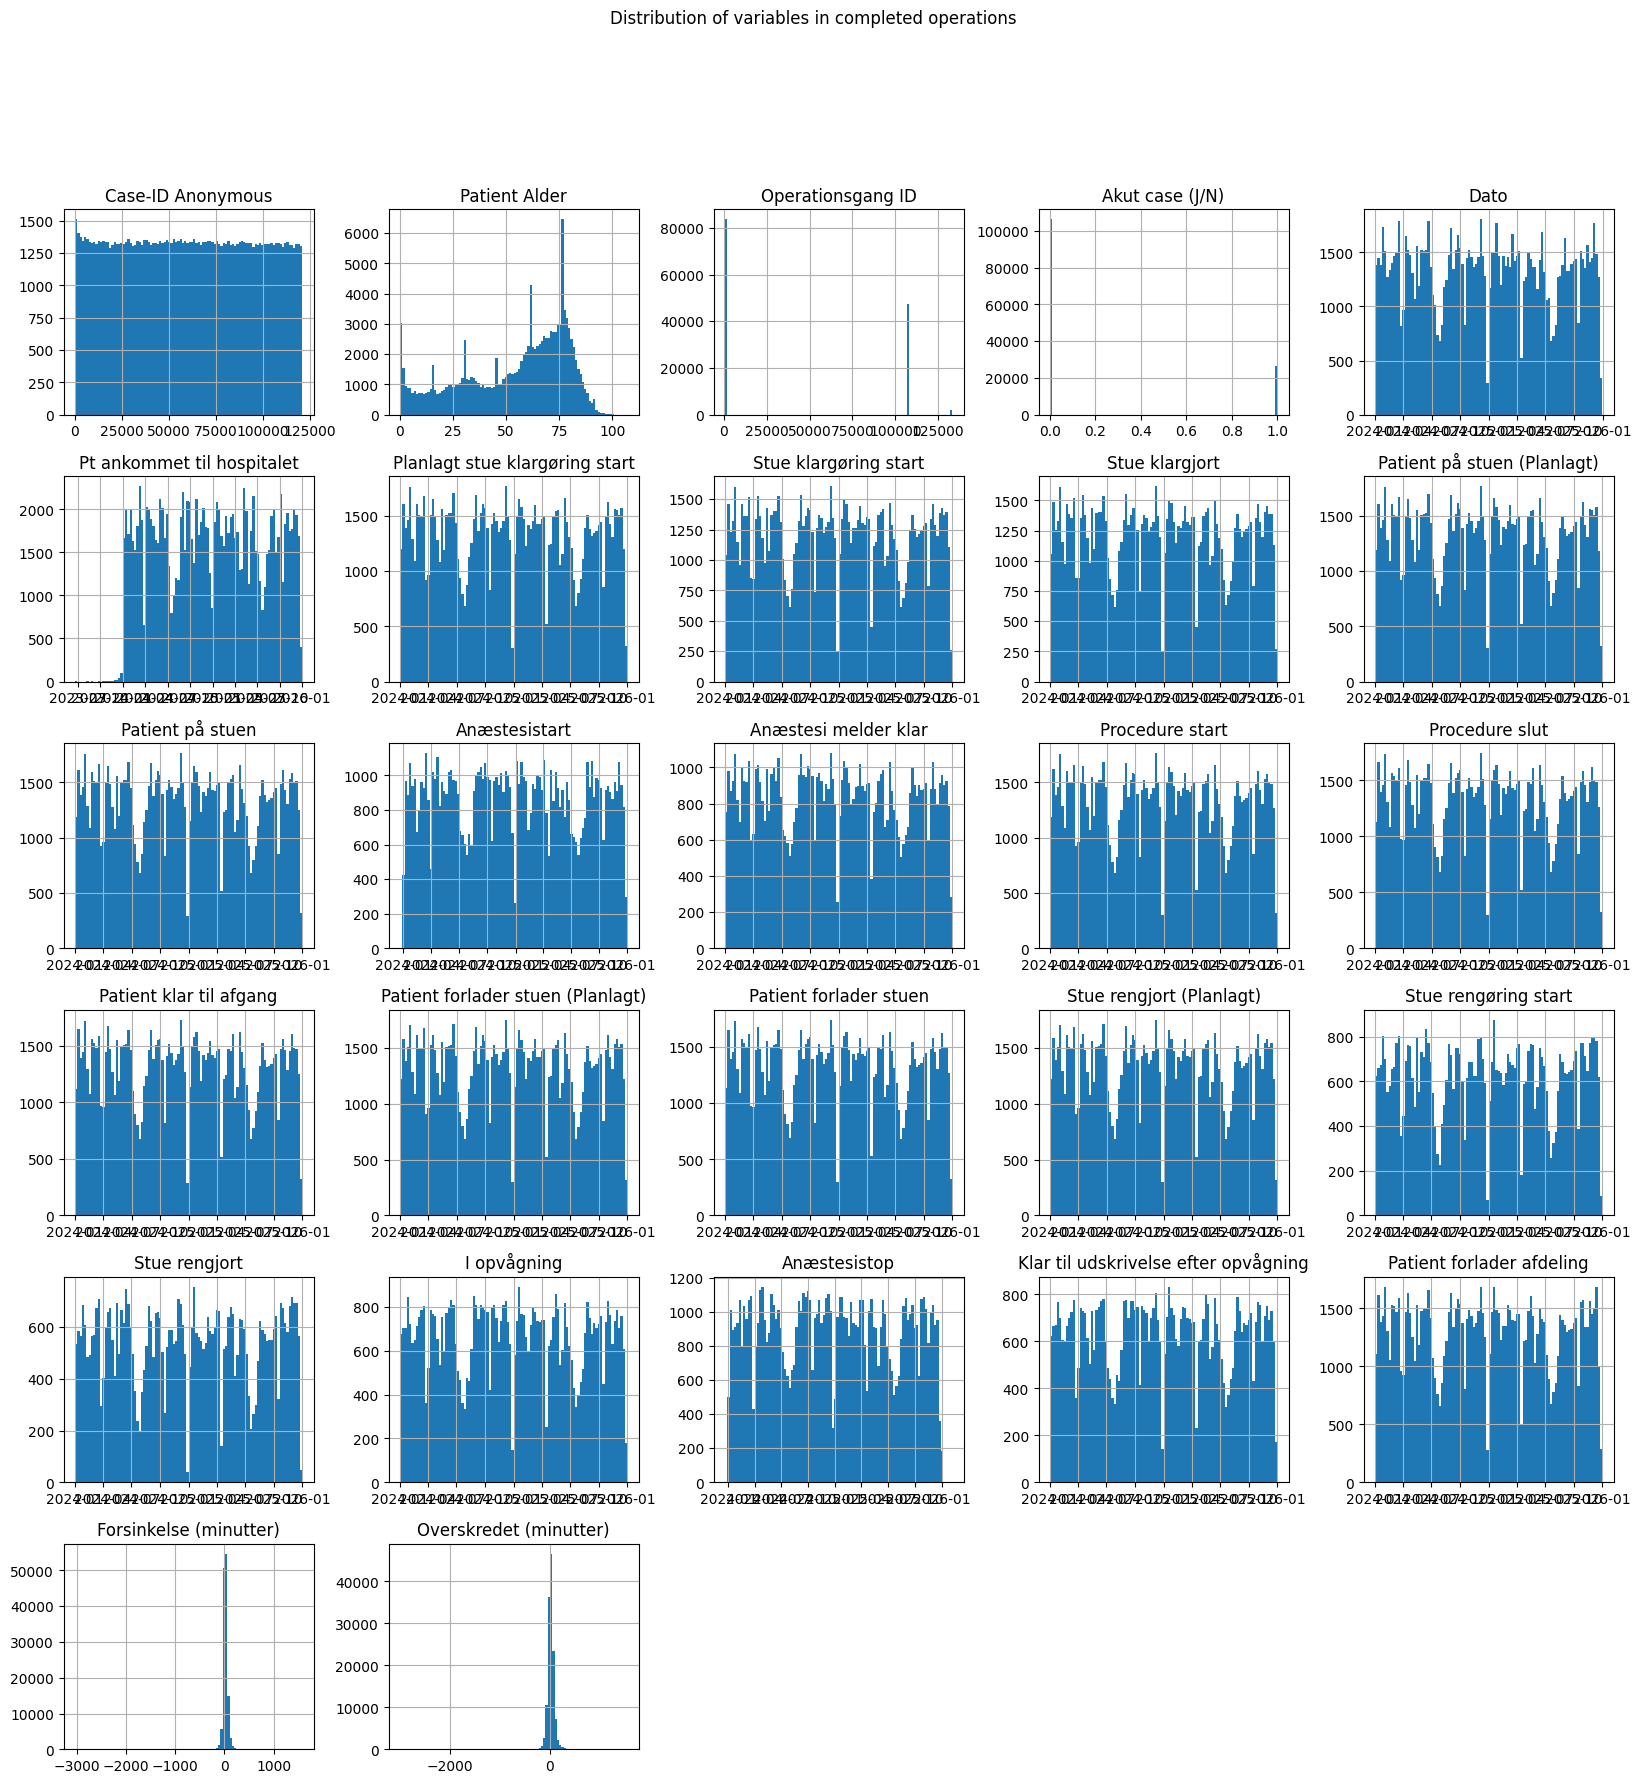

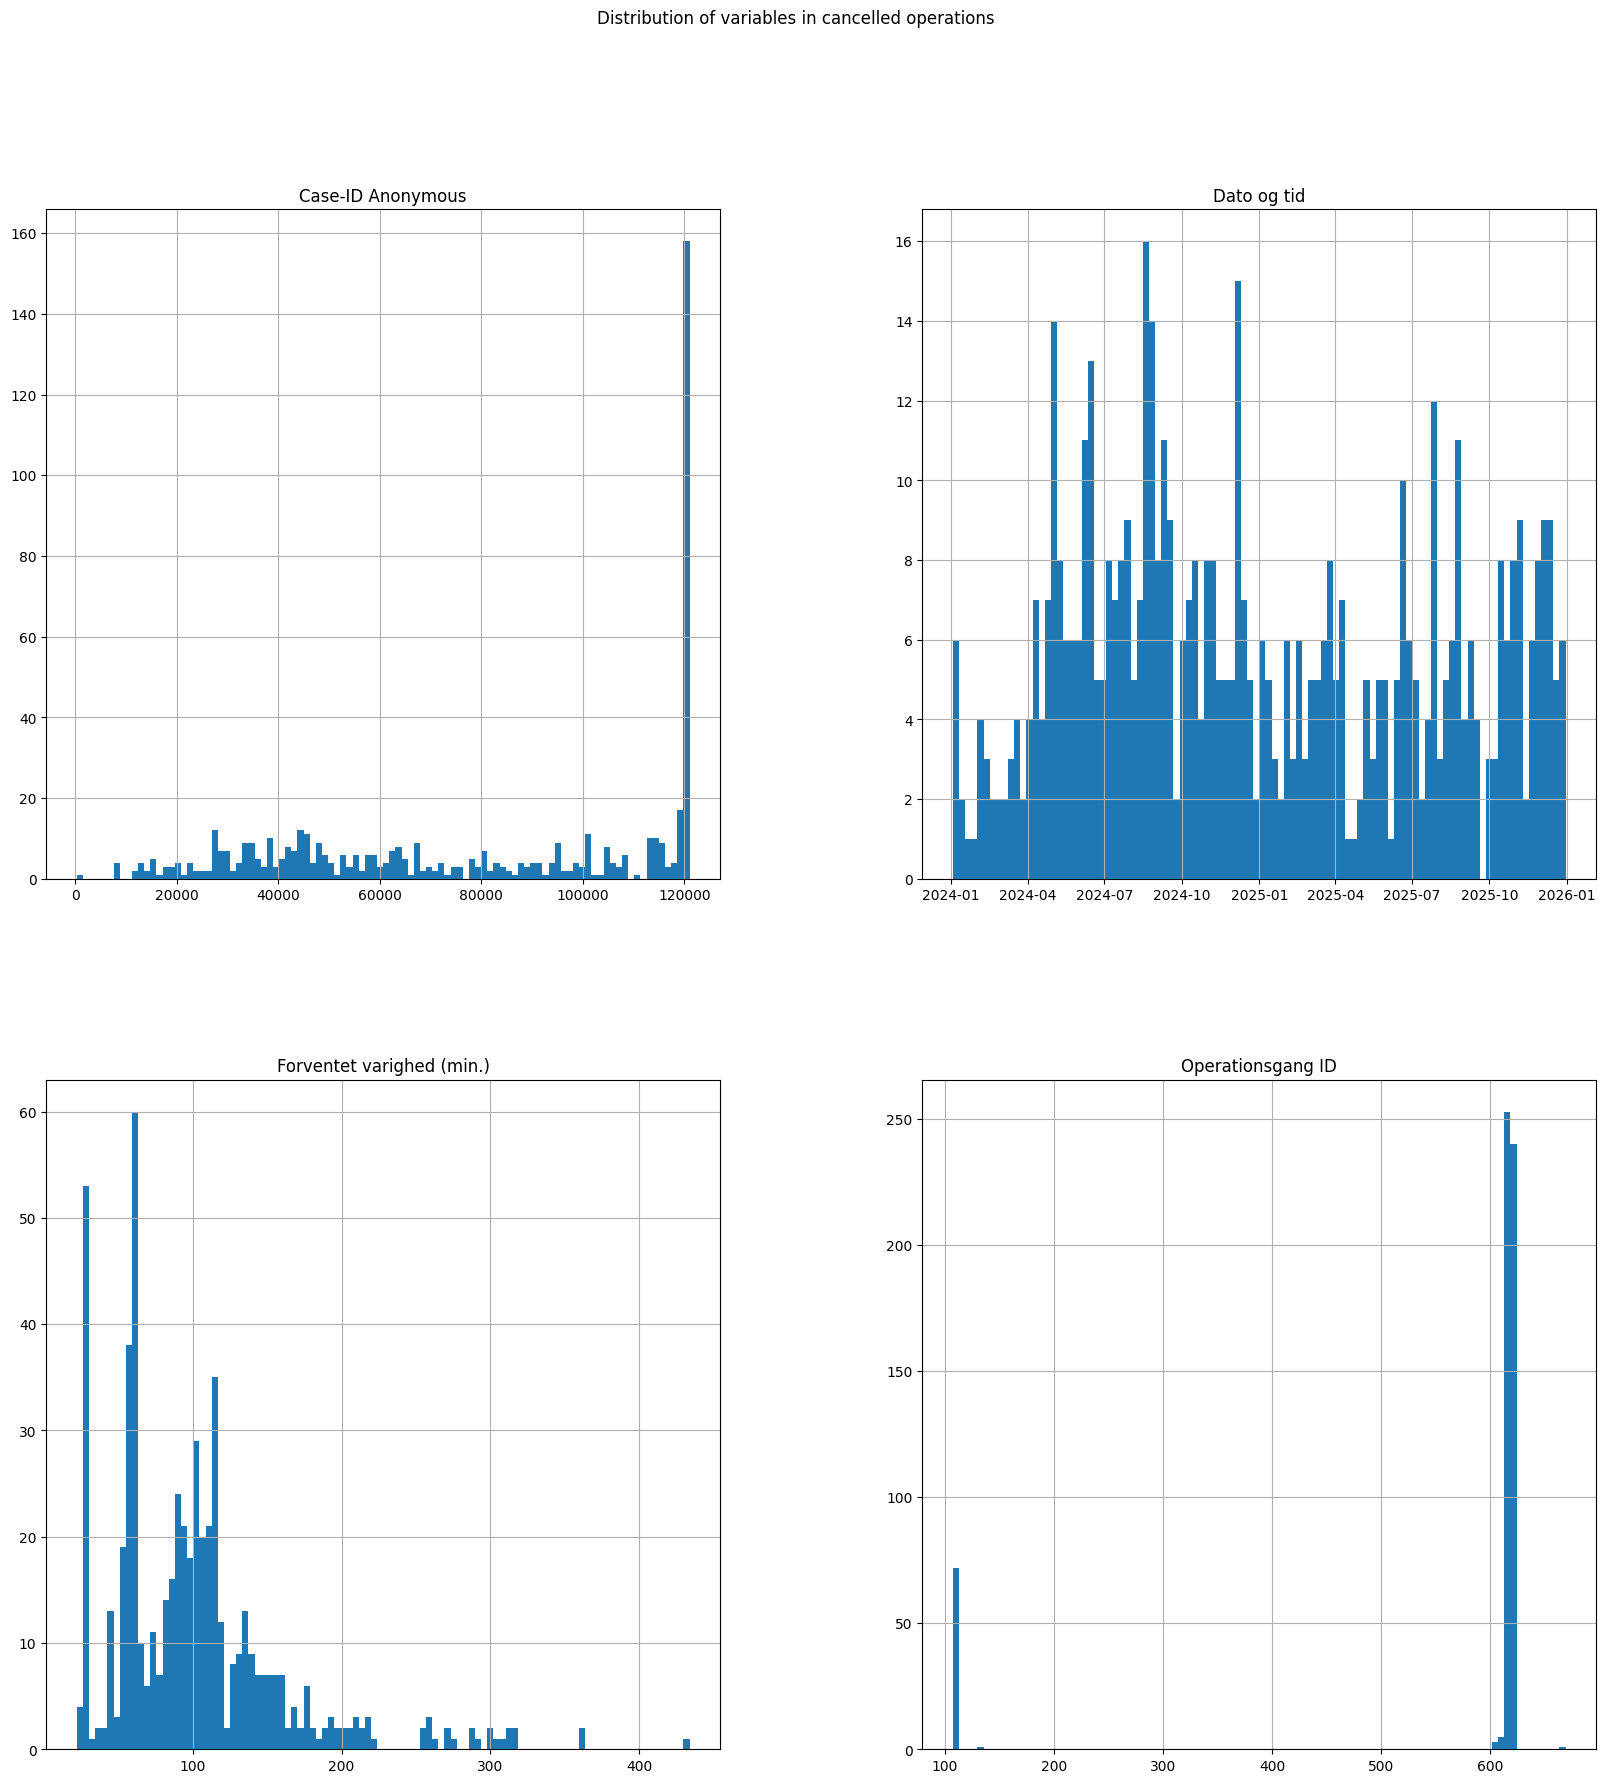

In [38]:
#visualize the distribution of the variables in the two dataframes using histograms
import matplotlib.pyplot as plt
#put bins for the histograms to 100

df_complete.hist(figsize=(20, 20), bins=100)
plt.suptitle("Distribution of variables in completed operations")
plt.show()
df_cancelled.hist(figsize=(20, 20), bins=100)
plt.suptitle("Distribution of variables in cancelled operations")
plt.show()


In [39]:
df_complete["Operationsgang ID"].nunique()

8

<Figure size 1200x600 with 0 Axes>

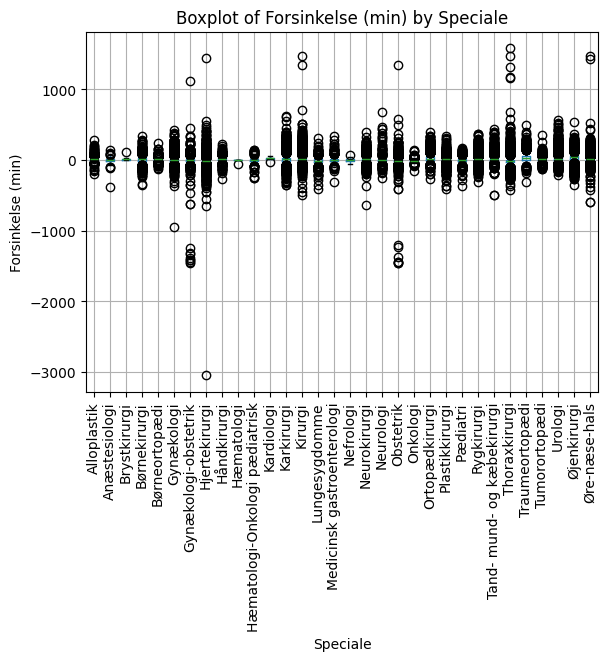

In [40]:
#plot forsinkelse for forskellige Procedure - Tekst & ID som boxplot 

import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
df_complete.boxplot(column='Forsinkelse (minutter)', by='Speciale', rot=90)
plt.title('Boxplot of Forsinkelse (min) by Speciale')
plt.suptitle('')
plt.xlabel('Speciale')
plt.ylabel('Forsinkelse (min)')
plt.show()



<Figure size 1200x600 with 0 Axes>

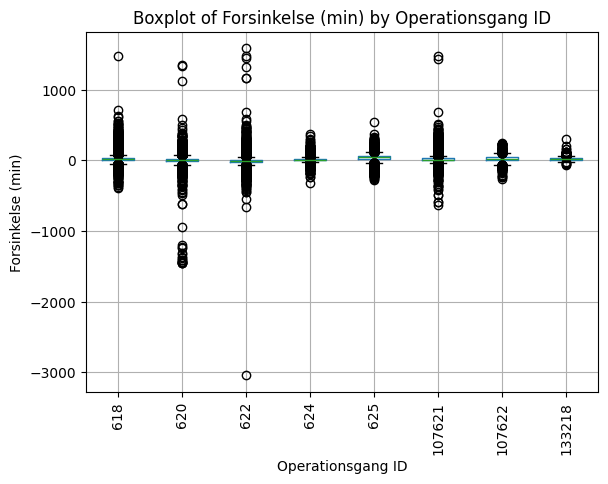

In [41]:
#plot forsinkelse for forskellige Procedure - Tekst & ID som boxplot 

import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
df_complete.boxplot(column='Forsinkelse (minutter)', by='Operationsgang ID', rot=90)
plt.title('Boxplot of Forsinkelse (min) by Operationsgang ID')
plt.suptitle('')
plt.xlabel('Operationsgang ID')
plt.ylabel('Forsinkelse (min)')
plt.show()

In [42]:
#print procendel af akutte values for alle specialer 

for speciale in df_complete['Speciale'].unique():
    total_cases = df_complete[df_complete['Speciale'] == speciale].shape[0]
    akut_cases = df_complete[(df_complete['Speciale'] == speciale) & (df_complete['Akut case (J/N)'] == 1)].shape[0]
    percentage_akut = (akut_cases / total_cases) * 100
    print(f"Speciale: {speciale}, Percentage of Akut cases: {percentage_akut:.2f}%")

Speciale: Øre-næse-hals, Percentage of Akut cases: 12.85%
Speciale: Plastikkirurgi, Percentage of Akut cases: 9.76%
Speciale: Tand- mund- og kæbekirurgi, Percentage of Akut cases: 11.74%
Speciale: Øjenkirurgi, Percentage of Akut cases: 8.49%
Speciale: Børnekirurgi, Percentage of Akut cases: 16.85%
Speciale: Ortopædkirurgi, Percentage of Akut cases: 37.38%
Speciale: Børneortopædi, Percentage of Akut cases: 3.31%
Speciale: Karkirurgi, Percentage of Akut cases: 34.72%
Speciale: Thoraxkirurgi, Percentage of Akut cases: 24.97%
Speciale: Hjertekirurgi, Percentage of Akut cases: 35.31%
Speciale: Urologi, Percentage of Akut cases: 25.41%
Speciale: Håndkirurgi, Percentage of Akut cases: 6.57%
Speciale: Kirurgi, Percentage of Akut cases: 45.01%
Speciale: Neurokirurgi, Percentage of Akut cases: 47.92%
Speciale: Pædiatri, Percentage of Akut cases: 12.90%
Speciale: Obstetrik, Percentage of Akut cases: 68.11%
Speciale: Gynækologi, Percentage of Akut cases: 24.85%
Speciale: Gynækologi-obstetrik, Perc

In [48]:
#print procentdel af akutte operationer 
total_cases = df_complete.shape[0]
akut_cases = df_complete[df_complete['Akut case (J/N)'] == 1].shape[0]
percentage_akut = (akut_cases / total_cases) * 100
print(f"Overall Percentage of Akut cases: {percentage_akut:.2f}%")


Overall Percentage of Akut cases: 20.01%


In [43]:
#print count forskellige specialer
print("Count of cases for each Speciale:")
print(df_complete['Speciale'].value_counts())

Count of cases for each Speciale:
Speciale
Øjenkirurgi                       40868
Øre-næse-hals                     14010
Plastikkirurgi                     9077
Rygkirurgi                         7346
Neurokirurgi                       6842
Tand- mund- og kæbekirurgi         6125
Karkirurgi                         5662
Thoraxkirurgi                      5258
Kirurgi                            5225
Hjertekirurgi                      4837
Gynækologi                         4623
Urologi                            4399
Børnekirurgi                       4165
Gynækologi-obstetrik               2006
Ortopædkirurgi                     1942
Obstetrik                          1872
Pædiatri                           1519
Tumorortopædi                      1208
Børneortopædi                      1089
Håndkirurgi                         974
Traumeortopædi                      965
Lungesygdomme                       855
Medicinsk gastroenterologi          536
Neurologi                           4

In [44]:
for col in df_complete.columns:
    print(col)

Case-ID Anonymous
Patient Alder
Speciale
Stue
Operationsgang ID
Akut case (J/N)
Dato
Pt ankommet til hospitalet
Planlagt stue klargøring start
Stue klargøring start
Stue klargjort
Patient på stuen (Planlagt)
Patient på stuen
Anæstesistart
Anæstesi melder klar
Procedure start
Procedure slut
Patient klar til afgang
Patient forlader stuen (Planlagt)
Patient forlader stuen
Stue rengjort (Planlagt)
Stue rengøring start
Stue rengjort
I opvågning
Anæstesistop
Klar til udskrivelse efter opvågning
Patient forlader afdeling
Forsinkelse (minutter)
Overskredet (minutter)
Forsinkelsesårsag
Procedure - Tekst & ID
Aktionsdiagnose - Kode & tekst
Aktionsdiagnose - Gruppe


### anæstelogi

In [45]:
#print Procedure – Tekst & ID for Speciale = Anæstesiologi
anæstesiologi_procedures = df_complete[df_complete['Speciale'] == 'Anæstesiologi']['Procedure - Tekst & ID'].unique()
print("Procedures for Speciale = Anæstesiologi:")
print(anæstesiologi_procedures)

Procedures for Speciale = Anæstesiologi:
['INVR TIPS [1070014291]' 'INVR ANGIOGRAFI UE [1070014284]'
 'INVR BLODPRØVETAGNING [1070018095]'
 'INVR ANGIOGRAFI ABDOMEN [1070014283]' 'INVR CHOLANGIOGRAFI [1070018090]'
 'INVR EMBOLISERING [1070014289]'
 'INVR DIAGNOSTISK ANGIOGRAFI/FLEBOGRAFI [1070014280]'
 'INVR PTC/DRÆNAGE [1070014293]' 'INVR SCLEROSERING [1070014290]'
 'INVR VENOGRAFI ABDOMEN [1070018091]' 'ENDOVASKULÆR-ANDET [1070013645]'
 'ENDOVASKULÆR-ANEURYSME [1070013639]'
 'INVR ANGIOGRAFI THORAX [1070014282]'
 'CT VEJLEDT VARMEBEHANDLING UA [1070011655]']


### øjenkirugi

In [51]:
#print Procedure – Tekst & ID for Speciale = Øjenkirurgi
øjenkirurgi_procedures = df_complete[df_complete['Speciale'] == 'Øjenkirurgi']['Procedure - Tekst & ID'].unique()
print("Procedures for Speciale = Øjenkirurgi:")
print(øjenkirurgi_procedures)


Procedures for Speciale = Øjenkirurgi:
['PTOSE, LEVATORKIRURGI - LA [1070010580]'
 'EKTROPION MED RETRAKTOR-, MEDIAL-,  OG LATERAL OPSTRAMNING - LA [1070010481]'
 'BLEPHAROPLASTIK, ØVRE BILATERAL - LA [1070010466]'
 'INTUBATION AF TÅREKANAL TIL TÅRESÆK, UNILATERAL - LA [1070010525]'
 'SONDERING AF TÅREKANAL, BILATERAL - LA [1070010611]'
 'ØJENLÅG, BIOPSI, INCISION OG ANDRE SMÅ INDGREB PÅ ØJENLÅG - LA [1070010652]'
 'CILIEPTOSE - LA [1070013348]'
 'ØJENLÅG, FJERNELSE AF TUMOR OG LIGNENDE, UDEN FRYS - LA [1070010654]'
 'KONJUNKTIVA, BIOPSI, KRYOBEHANDLING OG SUTUR - LA [1070010535]'
 'ORBITOTOMI, ANTERIOR - LA [1070010564]'
 'VITREKTOMI, ELEKTIV VR KIRURGI - LA [1070010670]'
 'VITREKTOMI OG FAKOEMULSIFIKATION MED IOL 25G - LA [1070013369]'
 'LUKNING AF TÅREKANAL - LA [1070010547]'
 'KRYOBEHANDLING/ELEKTROLYSEEPILATION FOR TRICHIASI - LA [1070010537]'
 'ENTROPION, RETRAKTORFORKORTNING OG/ELLER LATERAL TARSAL STRIP - LA [1070010490]'
 'VITREKTOMI 25G - LA [1070010668]'
 'EKTROPION, LATERAL

In [52]:
#print også count for de forskellige procedurer for øjenkirurgi
øjenkirurgi_procedure_counts = df_complete[df_complete['Speciale'] == 'Øjenkirurgi']['Procedure - Tekst & ID'].value_counts()
print("Procedure counts for Speciale = Øjenkirurgi:")
print(øjenkirurgi_procedure_counts)

Procedure counts for Speciale = Øjenkirurgi:
Procedure - Tekst & ID
FAKO 3 - LA [1070010664]                             6636
FAKO - LA BILATERAL [1070015679]                     6200
FAKO 1 - LA [1070010662]                             3577
FAKO 2 - LA [1070010663]                             2866
RECESSION AF ØJENMUSKEL - GA [1070013525]             906
                                                     ... 
INVR HOVED/HALS [1070018088]                            1
FJERNELSE AF IMPLANTAT I ORBITA - LA [1070010506]       1
MECHESKIFT AF ABSCES PÅ ØJENLÅG - GA [1070013485]       1
LUMBALPUNKTUR ALM MED I.S. KEMO [1070013210]            1
FAKO STENO - LA [1070016629]                            1
Name: count, Length: 403, dtype: int64


In [54]:
#print gns alder for alle specialer 
average_age_by_speciale = df_complete.groupby('Speciale')['Patient Alder'].mean()
print("Average age for each Speciale:")
print(average_age_by_speciale)

Average age for each Speciale:
Speciale
Alloplastik                       63.839196
Anæstesiologi                     56.036765
Brystkirurgi                      45.846154
Børnekirurgi                       5.763265
Børneortopædi                     13.168962
Gynækologi                        47.461172
Gynækologi-obstetrik              36.198903
Hjertekirurgi                     53.855489
Håndkirurgi                       41.436345
Hæmatologi                        29.500000
Hæmatologi-Onkologi pædiatrisk     8.571429
Kardiologi                        45.666667
Karkirurgi                        68.495231
Kirurgi                           59.932632
Lungesygdomme                     57.595322
Medicinsk gastroenterologi        57.000000
Nefrologi                         53.593220
Neurokirurgi                      54.745250
Neurologi                         70.325431
Obstetrik                         33.409722
Onkologi                          58.017949
Ortopædkirurgi                    45

gnsalder i KPH = 40,9

In [57]:
#print gns alder  
average_age = df_complete['Patient Alder'].mean()
print(f"Overall average age of patients: {average_age:.2f} years")

Overall average age of patients: 53.79 years


Percentage of each Speciale in relation to total cases:
Speciale
Øjenkirurgi                       30.691359
Øre-næse-hals                     10.521336
Plastikkirurgi                     6.816714
Rygkirurgi                         5.516755
Neurokirurgi                       5.138257
Tand- mund- og kæbekirurgi         4.599799
Karkirurgi                         4.252092
Thoraxkirurgi                      3.948693
Kirurgi                            3.923910
Hjertekirurgi                      3.632527
Gynækologi                         3.471815
Urologi                            3.303594
Børnekirurgi                       3.127863
Gynækologi-obstetrik               1.506481
Ortopædkirurgi                     1.458418
Obstetrik                          1.405849
Pædiatri                           1.140750
Tumorortopædi                      0.907193
Børneortopædi                      0.817825
Håndkirurgi                        0.731462
Traumeortopædi                     0.724703
Lungesygdom

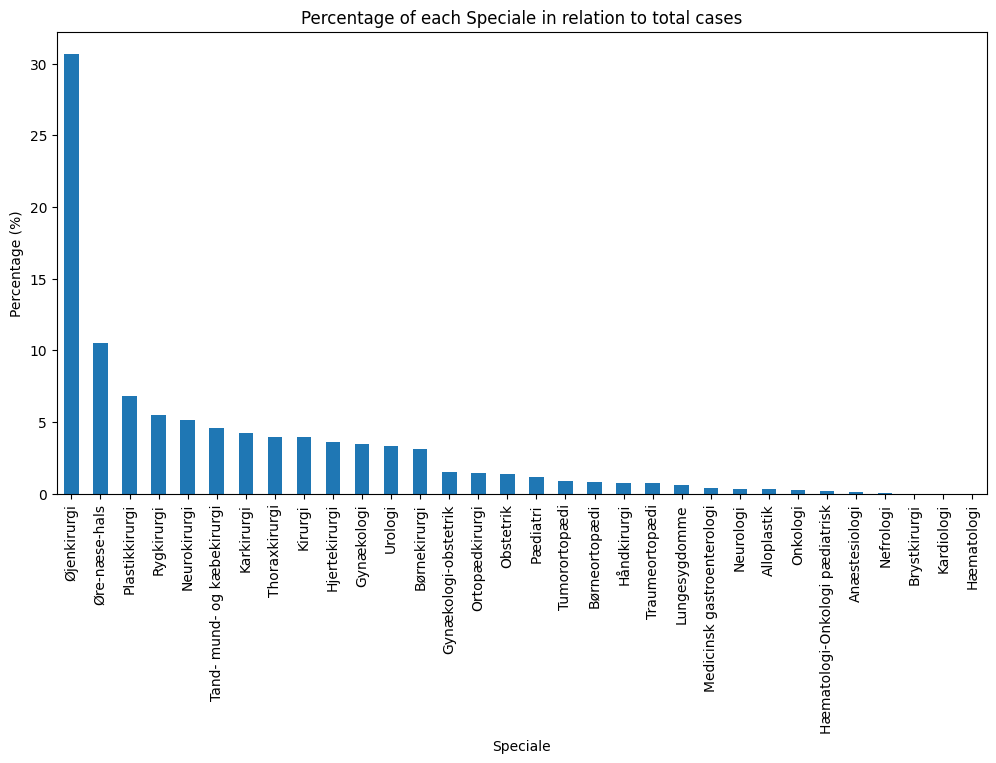

In [56]:
#print procentdel af hver speciale i forhold til totalen
total_cases = df_complete.shape[0]
speciale_counts = df_complete['Speciale'].value_counts()
percentage_by_speciale = (speciale_counts / total_cases) * 100
print("Percentage of each Speciale in relation to total cases:")
print(percentage_by_speciale)
#plot procentdel af hver speciale i forhold til totalen som bar chart
plt.figure(figsize=(12, 6))
percentage_by_speciale.plot(kind='bar')
plt.title('Percentage of each Speciale in relation to total cases')
plt.xlabel('Speciale')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=90)
plt.show()

## definerer sammensat datasæt

In [46]:
completed = df_complete.rename(columns={
    "Case ID Anonymous": "case_id",
    "Dato": "date",
    "Stue": "operating_room",
    "Operationsgang ID": "operation_hallway",
    "Procedure – Tekst": "procedure",
    "Aktionsdiagnose – tekst": "diagnosis",
    "Aktionsdiagnose – Gruppe": "diagnosis_group",
    "Patient Alder": "patient_age",
    "Akut case (J/N)": "is_acute",
    "Forsinkelse (minutter)": "delay_min",
    "Overskredet (minutter)": "overtime_min",
    "Forsinkelsesårsag": "delay_reason"
})

cancelled = df_cancelled.rename(columns={
    "Case ID Anonymous": "case_id",
    "Dato og tid": "date",
    "Stue": "operating_room",
    "Operationsgang ID": "operation_hallway",
    "Primær procedure – Tekst": "procedure",
    "Forventet varighed (min.)": "expected_duration_min",
    "Aflysningsårsag": "cancellation_reason",
    "Aflyst på dagen for operation?": "cancelled_same_day",
    "Aflyst efter operationsprogrammet er afsluttet?": "cancelled_after_planning",
    "Ombooket": "rebooked"
})

#tilføj status 
completed["status"] = "completed"
cancelled["status"] = "cancelled"

#sammenflet de to dataframes
df_all = pd.concat([completed, cancelled], ignore_index=True)

#print shape og kolonner i den nye dataframe
print("Shape of combined dataframe:", df_all.shape)
print("Columns in combined dataframe:", df_all.columns)
df_all.head()

Shape of combined dataframe: (133733, 40)
Columns in combined dataframe: Index(['Case-ID Anonymous', 'patient_age', 'Speciale', 'operating_room',
       'operation_hallway', 'is_acute', 'date', 'Pt ankommet til hospitalet',
       'Planlagt stue klargøring start', 'Stue klargøring start',
       'Stue klargjort', 'Patient på stuen (Planlagt)', 'Patient på stuen',
       'Anæstesistart', 'Anæstesi melder klar', 'Procedure start',
       'Procedure slut', 'Patient klar til afgang',
       'Patient forlader stuen (Planlagt)', 'Patient forlader stuen',
       'Stue rengjort (Planlagt)', 'Stue rengøring start', 'Stue rengjort',
       'I opvågning', 'Anæstesistop', 'Klar til udskrivelse efter opvågning',
       'Patient forlader afdeling', 'delay_min', 'overtime_min',
       'delay_reason', 'Procedure - Tekst & ID',
       'Aktionsdiagnose - Kode & tekst', 'Aktionsdiagnose - Gruppe', 'status',
       'Primær procedure - Tekst', 'cancelled_after_planning',
       'Aflyst på dagen for operati

,Case-ID Anonymous,patient_age,Speciale,operating_room,operation_hallway,is_acute,date,Pt ankommet til hospitalet,Planlagt stue klargøring start,Stue klargøring start,...,Procedure - Tekst & ID,Aktionsdiagnose - Kode & tekst,Aktionsdiagnose - Gruppe,status,Primær procedure - Tekst,cancelled_after_planning,Aflyst på dagen for operationen?,cancellation_reason,expected_duration_min,rebooked
0,28,29.0,Øre-næse-hals,OPNORD 23.240 (H),107621.0,0.0,2024-03-07,2024-03-07 10:51:00,2024-03-07 12:05:00,2024-03-07 13:05:00,...,AURES ALATAE [1070010290],DQ175: Aures alatae,"Medfødte misdannelser i øje, øre, ansigtet og ...",completed,NaN,NaN,NaN,NaN,NaN,NaN
1,197,60.0,Plastikkirurgi,OPNORD 13.114 (H),107621.0,0.0,2024-01-05,2024-01-05 12:44:00,2024-01-05 13:40:00,2024-01-05 13:48:00,...,"ARKORREKTION, TRUNCUS -LA [1070012770]",DZ421: Kontakt mhp. plastikkirurgisk efterbeha...,Personer i kontakt med sundhedsvæsenet med hen...,completed,NaN,NaN,NaN,NaN,NaN,NaN
2,197,60.0,Plastikkirurgi,OPNORD 13.114 (H),107621.0,0.0,2024-01-05,2024-01-05 12:44:00,2024-01-05 13:40:00,2024-01-05 13:48:00,...,"BRYSTKORREKTION VED ASYMMETRI -LA, LIPOINJEKTI...",DZ421: Kontakt mhp. plastikkirurgisk efterbeha...,Personer i kontakt med sundhedsvæsenet med hen...,completed,NaN,NaN,NaN,NaN,NaN,NaN
3,230,12.0,Plastikkirurgi,OPNORD 13.110 (H),107621.0,0.0,2024-01-26,2024-01-26 08:15:00,2024-01-26 08:00:00,2024-01-26 08:16:00,...,"ARKORREKTION, HOVED OG HALS LA [1070010676]",DZ429: Kontakt mhp. plastikkirurgisk efterbeha...,Personer i kontakt med sundhedsvæsenet med hen...,completed,NaN,NaN,NaN,NaN,NaN,NaN
4,238,57.0,Plastikkirurgi,OPNORD 301,107621.0,0.0,2024-10-01,2024-10-01 12:14:00,2024-10-01 12:45:00,2024-10-01 13:01:00,...,"EXCISION, BENIGN TUMOR, TRUNCUS -LA [1070010711]",DQ850: Ikke-malign neurofibromatose,Andre medfødte misdannelser,completed,NaN,NaN,NaN,NaN,NaN,NaN


## definer target variable, for om der er cancelled

In [47]:
df_complete["Cancelled"] = 0
df_cancelled["Cancelled"] = 1
common_cols = list(set(df_complete.columns).intersection(df_cancelled.columns))

df_all = pd.concat([
    df_complete[common_cols],
    df_cancelled[common_cols]
])

print("Shape of combined dataset:", df_all.shape)

Shape of combined dataset: (133733, 4)


Men kun 575 cancelled.

👉 Det er meget ubalanceret (0.4% cancelled)

Det bliver en modelling-udfordring.